In [1]:
# Imports

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/weather.csv", parse_dates = ['time'])
df.sample(5)

,time,temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,rain,snowfall,weather_code,cloud_cover,pressure_msl,surface_pressure,wind_speed_10m,wind_direction_10m,shortwave_radiation,vapour_pressure_deficit,soil_temperature_0_to_7cm
184072,2020-12-30 16:00:00,-2.0,74,-6.1,0.0,0.0,0.0,3,100,1006.7,883.3,6.8,252,134.0,0.14,-1.0
66005,2007-07-13 05:00:00,14.1,89,12.4,0.0,0.0,0.0,0,0,1016.7,898.6,4.0,265,0.0,0.17,15.7
34530,2003-12-09 18:00:00,-7.5,69,-12.3,0.0,0.0,0.0,0,0,1026.7,898.5,2.5,262,5.0,0.11,-8.6
85582,2009-10-05 22:00:00,1.1,78,-2.3,0.0,0.0,0.0,3,96,1014.8,891.7,9.0,209,0.0,0.14,3.2
196909,2022-06-18 13:00:00,18.8,63,11.6,0.0,0.0,0.0,1,23,1004.1,889.2,1.1,99,796.0,0.81,15.3


In [3]:
# Inspect

# Structure
print("Shape:", df.shape, "\n")
print(df.dtypes, "\n")

# Missingness
print("Null Sum:", "\n", df.isna().sum(), "\n")
print("Null %:", "\n", df.isna().mean().mul(100).round(2), "\n")

# Duplicates
print("Duplicated Rows:", df[df.duplicated(keep = False)], "\n")
print("Duplicated Time:", df[df['time'].duplicated(keep = False)], "\n")

# Sanity
print(df['time'].min(), "to", df['time'].max(), "\n")
print("Monotonic:", df['time'].is_monotonic_increasing, "\n")
print(df['time'].diff().value_counts(), "\n")
print(df.describe().T)

Shape: (233760, 16) 

time                         datetime64[us]
temperature_2m                      float64
relative_humidity_2m                  int64
dew_point_2m                        float64
precipitation                       float64
rain                                float64
snowfall                            float64
weather_code                          int64
cloud_cover                           int64
pressure_msl                        float64
surface_pressure                    float64
wind_speed_10m                      float64
wind_direction_10m                    int64
shortwave_radiation                 float64
vapour_pressure_deficit             float64
soil_temperature_0_to_7cm           float64
dtype: object 

Null Sum: 
 time                         0
temperature_2m               0
relative_humidity_2m         0
dew_point_2m                 0
precipitation                0
rain                         0
snowfall                     0
weather_code                 

In [4]:
# Clean
# No clean required after inspection.

In [5]:
# Transform

time_df = (
    df.loc[(df["time"].dt.month.eq(8)) & (df["time"].dt.year.eq(2025)), ["time", "relative_humidity_2m"]]
      .assign(hour=lambda x: x["time"].dt.hour)
      .drop(columns="time")
      .groupby("hour")
      .mean()
      .round(2)
)

time_df

,relative_humidity_2m
hour,
0,80.45
1,82.52
2,83.58
3,84.71
4,86.42
5,87.06
6,87.81
7,87.61
8,82.23


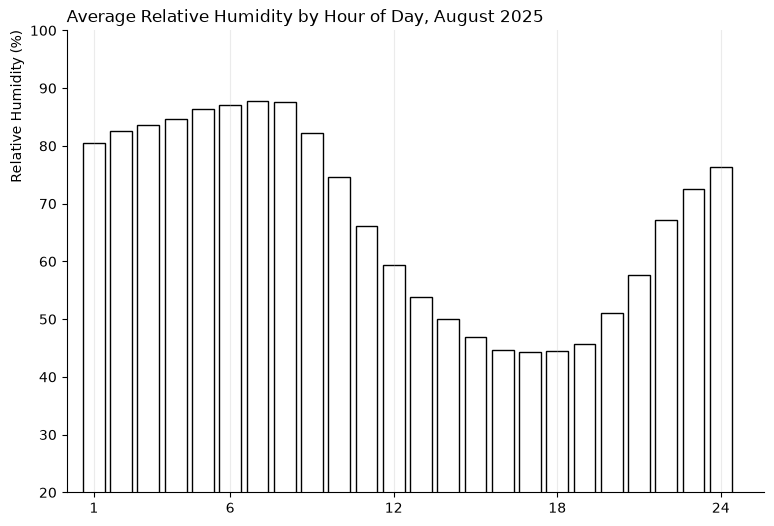

In [6]:
# Visualize

fig, ax = plt.subplots(figsize=(9, 6))

ax.bar(time_df.index + 1, time_df["relative_humidity_2m"], facecolor = 'w', edgecolor = 'k')

ax.set_ylim(20, 100)
ax.set_ylabel("Relative Humidity (%)", loc="top")

ax.set_xlim(0,)
ax.set_xticks([1, 6, 12, 18, 24])
ax.grid(axis="x", which="major", alpha=0.25)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.set_title("Average Relative Humidity by Hour of Day, August 2025", loc="left")

fig.savefig("outputs/august_avg_humidity_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()